# Singular expansion methods

## Lindstedt-Poincare
The Lindstedt-Poincaré method is a perturbation technique used to find approximate solutions to nonlinear differential equations. It is particularly useful for oscillatory systems where regular perturbation methods fail due to secular terms that cause unbounded growth. The method introduces a rescaling of time (a frequency shift) as part of the expansion procedure, which eliminates these problematic secular terms and allows for the construction of uniformly valid asymptotic solutions over long time scales.

### Strained Coordinate

The key innovation of the Lindstedt-Poincaré method is the introduction of a **strained coordinate** (or stretched time variable):

$$\tau = \omega \cdot t$$

where $\omega = 1 + \epsilon \omega_1 + \epsilon^2 \omega_2 + \ldots$ is the frequency correction that depends on the perturbation parameter $\epsilon$.

### First and Second Order Derivatives

When expressed in terms of the strained coordinate $\tau$, the derivatives transform as:

$$\frac{d}{dt} = \omega \frac{d}{d\tau}$$

$$\frac{d^2}{dt^2} = \omega^2 \frac{d^2}{d\tau^2}$$

To first order in $\epsilon$:

$$\frac{d}{dt} \approx (1 + \epsilon \omega_1) \frac{d}{d\tau}$$

$$\frac{d^2}{dt^2} \approx (1 + 2\epsilon \omega_1) \frac{d^2}{d\tau^2}$$

These transformed derivatives are then substituted into the original differential equation, and coefficients of equal powers of $\epsilon$ are collected to obtain successive order approximations for both the solution and the frequency corrections $\omega_1, \omega_2, \ldots$.

## First example
Our first example
$$
\ddot{u}+\omega^2_0 u=\epsilon u, \ u(0)=a, \dot{u}(0)=0, \ 0 < \epsilon << 1
$$ 

With analytic solution

$$ 
u= a cos(\omega_0 \displaystyle\sqrt{1-\frac{\epsilon}{\omega^2_0}}t )
$$ 

and our straight forward expansion

$$
u_{2T}= a \cos(\omega_0 t)+ \frac{a \epsilon t}{2\omega_0} \sin(\omega_0 t) + O(\epsilon^2)
$$

$$
u_{2LP}= a \cos\left(\omega_0 (1-\frac{\epsilon}{2\omega_0^2}-\frac{\epsilon^2}{8*\omega_0^4}) t\right)
$$



In [16]:
import numpy as np
import matplotlib.pyplot as plt

def ex1_exact(t,a=1,omega_0=1,epsilon=0.1):
    return a*np.cos(omega_0*np.sqrt(1-epsilon/omega_0**2)*t) 

def ex1_expanded(t,a=1,omega_0=1,epsilon=0.1):
    return a*np.cos(omega_0*t) + a*epsilon*t/2/omega_0*np.sin(omega_0*t)

def ex1_LP(t,a=1,omega_0=1,epsilon=0.1):
    phase=omega_0*t*(1-epsilon/2/omega_0**2-epsilon**2/8/omega_0**4)
    return a*np.cos(phase)

def plot_ex1(epsilon=0.1):
    t = np.linspace(0, 2.5/epsilon, 1000)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(t, ex1_exact(t, epsilon=epsilon), label='Exact', linewidth=2)
    ax1.plot(t, ex1_expanded(t, epsilon=epsilon), label='Expanded (2nd order)', linewidth=2, linestyle='--')
    ax1.plot(t, ex1_LP(t, epsilon=epsilon), label='Low-order (LP)', linewidth=2, linestyle='-.')
    
    ax1.axvline(x=1/epsilon, color='red', linestyle=':', linewidth=1.5, label=f't=1/ε={1/epsilon:.1f}')
    ax1.set_xlabel('t')
    ax1.set_ylabel('u(t)')
    ax1.legend()
    ax1.grid(True)
    ax1.set_title(f'Example 1: Solutions (ε={epsilon})')
    
    error = np.abs(ex1_exact(t, epsilon=epsilon) - ex1_expanded(t, epsilon=epsilon))
    error_LP = np.abs(ex1_exact(t, epsilon=epsilon) - ex1_LP(t, epsilon=epsilon))
    ax2.plot(t, error, label='Error (Expanded)', linewidth=2)
    ax2.plot(t, error_LP, label='Error (LP)', linewidth=2, linestyle='--')
    ax2.axvline(x=1/epsilon, color='red', linestyle=':', linewidth=1.5, label=f't=1/ε={1/epsilon:.1f}')
    
    ax2.set_xlabel('t')
    ax2.set_ylabel('|Error|')
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True)
    ax2.set_title(f'Example 1: Error (ε={epsilon})')
    
    
    plt.show()

interact(plot_ex1, epsilon=FloatSlider(min=0.005, max=0.5, step=0.005, value=0.001));
     

interactive(children=(FloatSlider(value=0.005, description='epsilon', max=0.5, min=0.005, step=0.005), Output(…

## Second example where Lindstedt-Poincare doesn't work. 
$$
\ddot{u}+ u =- \epsilon \dot{u}, \ u(0)=1, \dot{u}(0)=0, \ 0 < \epsilon << 1
$$ 

With analytic solution

$$ 
u_{ex}= e^{-\epsilon t/2}\left[ cos(\omega t) + \frac{\epsilon}{2 \omega} \sin(\omega t) \right] 
$$
with 
$$
\omega=\displaystyle\sqrt{1-\left(\frac{\epsilon}{2}\right)^2}
$$

and our straight forward expansion

$$
u_{2T}= \cos(t)- \frac{ \epsilon}{2} \left(t \cos(t) - \sin(t)\right) + O(\epsilon^2)
$$

Lindstedt-Poincare gives for $O(\epsilon)$ problem 
$$
\frac{d}{d\tau}u_1+u_1=\sin(\tau)+\omega_1 \cos(\tau), u_1 (0)=\frac{d}{d\tau} (0)=0.
$$
Both terms on the right-hand side gives rise to sekular terms. Cannot get rid of bot. 


In [31]:
def ex2_exact(t,epsilon=0.1):
    omega=np.sqrt(1-(0.5*epsilon)**2)
    sol = np.exp(-epsilon*t/2)*(np.cos(omega*t) + (epsilon/2/omega)*np.sin(omega*t))
    return sol


def plot_ex2(epsilon=0.1):
    t = np.linspace(0, 60, 1000)

    fig, ax = plt.subplots(1,1,figsize=(12, 5))
    
    ax.plot(t, ex2_exact(t, epsilon=epsilon), label='Exact', linewidth=2)
    ax.plot(t, ex2_expanded(t, epsilon=epsilon), label='Expanded (1st order)', linewidth=2, linestyle='--')
    ax.plot(t, np.exp(-epsilon*t/2), label=f'Envelope: $e^{{-\\epsilon t/2}}$', linewidth=2, linestyle=':', color='red')
    ax.plot(t, -np.exp(-epsilon*t/2), linewidth=2, linestyle=':', color='red')
        
    ax.set_xlabel('t')
    ax.set_ylabel('u(t)')
    ax.legend()
    ax.grid(True)
    
    ax.set_title(f'Example 2: Damped Oscillator (ε={epsilon})')
    plt.show()

interact(plot_ex2, epsilon=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1));



interactive(children=(FloatSlider(value=0.1, description='epsilon', max=0.5, min=0.01, step=0.01), Output()), …

After doing 

In [24]:
def ex2_exact(t,epsilon=0.1):
    omega=np.sqrt(1-(0.5*epsilon)**2)
    sol = np.exp(-epsilon*t/2)*(np.cos(omega*t) + (epsilon/2/omega)*np.sin(omega*t))
    return sol

def ex2_expanded(t,epsilon=0.1):
    sol = np.exp(-epsilon*t/2)*np.cos(t)
    return sol
def plot_ex2(epsilon=0.1):
    t = np.linspace(0, 30, 1000)

    fig, axs = plt.subplots(2,1,figsize=(12, 5))
    ax = axs[0]
    ax2 = axs[1]
        
    ax.plot(t, ex2_exact(t, epsilon=epsilon), label='Exact', linewidth=2)
    ax.plot(t, ex2_expanded(t, epsilon=epsilon), label='Expanded (1st order)', linewidth=2, linestyle='--')
    ax.plot(t, np.exp(-epsilon*t/2), label=f'Envelope: $e^{{-\\epsilon t/2}}$', linewidth=2, linestyle=':', color='red')
    ax.plot(t, -np.exp(-epsilon*t/2), linewidth=2, linestyle=':', color='red')
        
    ax.set_xlabel('t')
    ax.set_ylabel('u(t)')
    ax.legend()
    ax.grid(True)
    error = np.abs(ex2_exact(t, epsilon=epsilon) - ex2_expanded(t, epsilon=epsilon))
    ax2.plot(t, error, label='Error (Expanded)', linewidth=2)
    ax2.set_xlabel('t')
    ax2.set_ylabel('|Error|')
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True)
    ax.set_title(f'Example 2: Damped Oscillator (ε={epsilon})')
    plt.show()

interact(plot_ex2, epsilon=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1));



interactive(children=(FloatSlider(value=0.1, description='epsilon', max=0.5, min=0.01, step=0.01), Output()), …


## Van der Pol Oscillator

The Van der Pol oscillator is a classic nonlinear dynamical system described by the differential equation:

$$\ddot{x} + \mu(1 - x^2)\dot{x} + x = 0$$

where $\mu > 0$ is a parameter controlling the strength of the nonlinearity. This equation models a self-excited oscillator with nonlinear damping and arises in various physical applications, including electrical circuits, mechanical systems, and biological phenomena.

### Key Features

**Nonlinear Damping**: The term $\mu(1 - x^2)\dot{x}$ represents velocity-dependent damping that is negative (energy-adding) when $|x| < 1$ and positive (energy-dissipating) when $|x| > 1$. This creates a self-sustaining oscillation.

**Limit Cycle**: For any initial condition, trajectories in phase space spiral toward a stable periodic orbit called a **limit cycle**. This behavior is independent of initial conditions and depends only on the parameter $\mu$.

**Perturbation Methods**: The Van der Pol equation serves as an important test case for perturbation techniques. For small $\mu$ (weakly nonlinear regime), methods like the Lindstedt-Poincaré approach can be used to approximate the solution analytically. As $\mu$ increases, the oscillations become increasingly nonlinear, with sharp transitions between slow and fast dynamics.

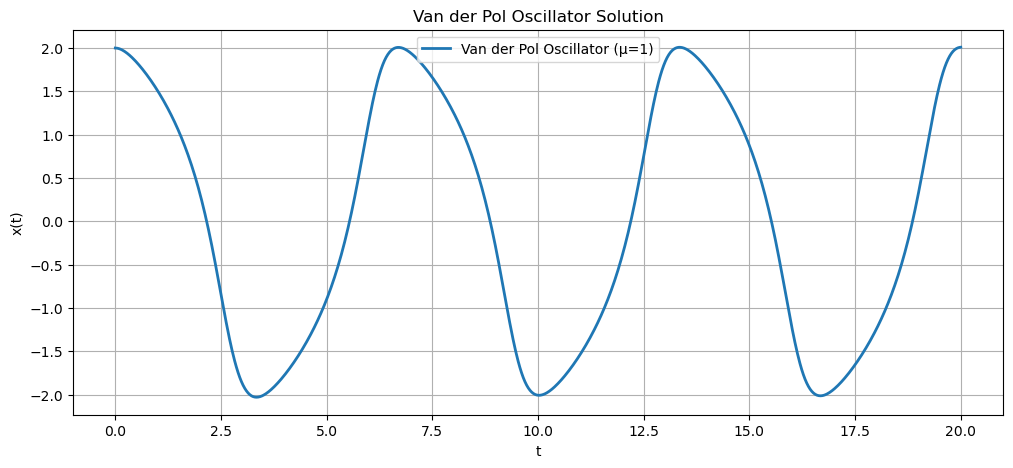

In [27]:
from scipy.integrate import solve_ivp
def van_der_pol_expanded(t, mu=1):
    # This is a placeholder for the exact solution of the Van der Pol oscillator
    # The actual solution is complex and typically requires numerical methods
    return np.cos(t)  # Replace with actual solution if known

def van_der_pol_rhs(t, y, mu=1):
    x, dxdt = y
    d2xdt2 = mu * (1 - x**2) * dxdt - x
    return [dxdt, d2xdt2]

solver = solve_ivp(van_der_pol_rhs, [0, 20], [2, 0], args=(1,), t_eval=np.linspace(0, 20, 1000))
t = solver.t
x = solver.y[0] 
plt.figure(figsize=(12, 5))
plt.plot(t, x, label='Van der Pol Oscillator (μ=1)', linewidth=2)
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Van der Pol Oscillator Solution')
plt.grid(True)
plt.legend()
plt.show()


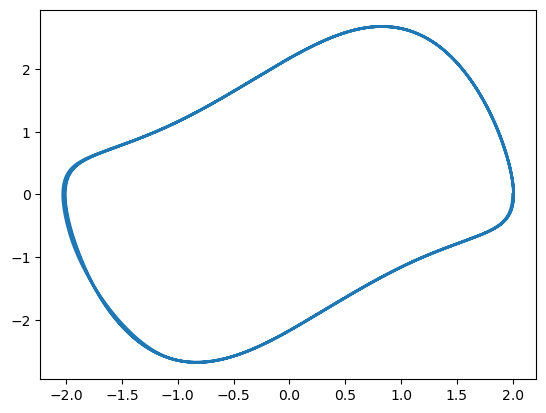

In [28]:
plt.plot(solver.y[0], solver.y[1], label='Phase Space Trajectory', linewidth=2)